In [3]:
# A fidi is the joint distribution of a stochastic process evaluated at a finite collection of time points. 
# Fidis can be of any finite size. The collection of all such joint distributions determines the distribution of the entire process. 
# Since all Brownian motion fidis are multivariate normal, Brownian motion is a Gaussian process.

In [ ]:
# Brownian Bridge

# Let W_{t} be a Brownian motion on [0,1].
# A Brownian bridge is defined at B_{t} = W_{t} - t*W_{1}.
        # This "ties down" the Brownian path with conditions B_{0}=0 and B_{1}=0 
        # The idea is to smoothly enforce the endpoint constraint
# Properties
    # E[B_{t}] = 0
    # Cov(B_{s},B_{t}) = min(s,t) - st
        # Explanation: The covariance (randomness) is the shared Brownian randomness (min(s,t)) and a correction for "tying down" at t=1
    # Since a Brownian Bridge is normal, the mean and variance are the two functions necessary to describe the distribution.

# Conceptual Defn
    # Brownian motion is a Gaussian process because all its finite-dimensional distributions (fidis) are multivariate normal.
    # A Brownian bridge is a linear transformation of Brownian motion, so it's fidis are also multivariate normal.
    # This makes a Brownian bridge a Gaussian process.
    # The transformation in a bridge subtracts a linear term to smoothly enforce the contition B_{1}=0 as to preserve continuity.




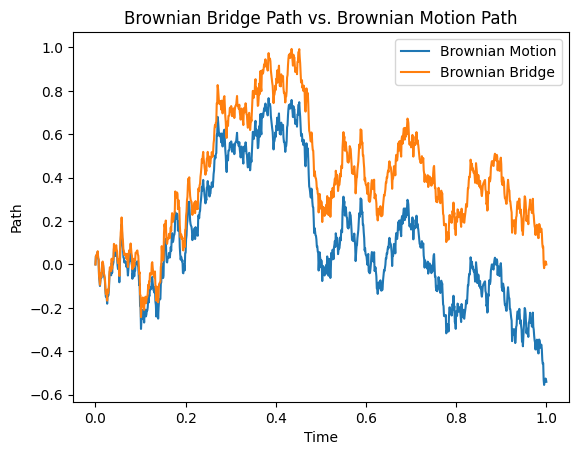

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters #

# time
T=1.0
#increments
n=1000
dt=T/n

# simulate increments to form one Brownian Path
Z=np.random.normal(0,1,n)
dW = np.sqrt(dt) * Z
W=np.cumsum(dW)
# Initial condition
W = np.insert(W,0,0) 

t=np.linspace (0, T, n+1)

# Create Brownian Bridge
W1 = W[-1]
B = W - t*W1

plt.plot(t, W, label = "Brownian Motion")
plt.plot(t,B, label = "Brownian Bridge")
plt.title("Brownian Bridge Path vs. Brownian Motion Path")
plt.xlabel("Time")
plt.ylabel("Path")
plt.legend()
plt.show()




In [ ]:
# Demonstrates that Brownian Bridge smoothly enforces the endpoint condition.
# The paths look extremely similar at every step. Over time, the bridge is brought closer to the end constraint.

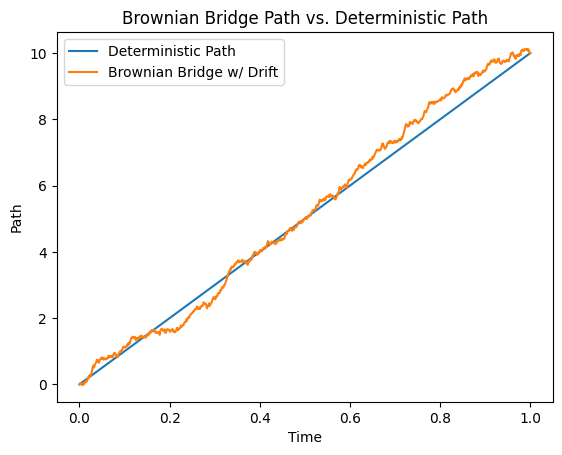

In [4]:
# Brownian motion with linear drift

# Up to now, we've looked at Brownian motion as randomness fluctuating around a mean of 0. 
# What happens when we add in a deterministic trend?
# Note: Using Brownian bridge here as well.



# simulate increments to form one Brownian Path
Z=np.random.normal(0,1,n)
dW = np.sqrt(dt) * Z
W=np.cumsum(dW)
# Initial condition
W = np.insert(W,0,0) 

t=np.linspace (0, T, n+1)

# Create Brownian Bridge
W1 = W[-1]
B = W - t*W1

# Deterministic vector (Vector of values of the function f(t)= 10t at nodes in our mesh)
x = 10*t

Y = x + B

# plot
plt.plot(t, x, label = "Deterministic Path")
plt.plot(t,Y, label = "Brownian Bridge w/ Drift")
plt.title("Brownian Bridge Path vs. Deterministic Path")
plt.xlabel("Time")
plt.ylabel("Path")
plt.legend()
plt.show()

Mean (theoretical ~ $\mu$): 5.0057572469654135
Variance (theoretical ~ $\sigma^2$): 8.877742031977858


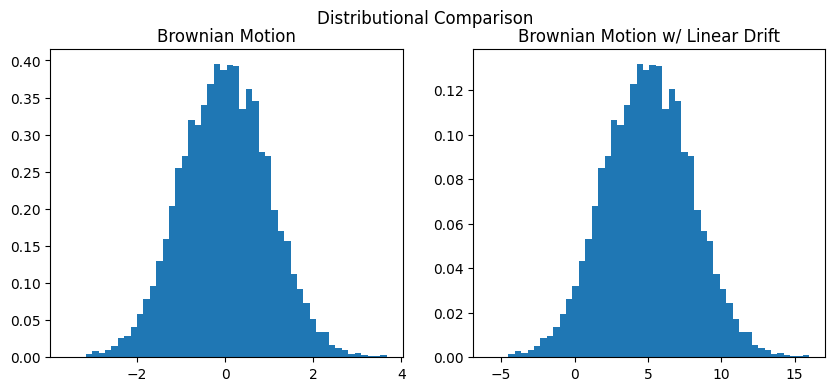

In [6]:
# Above, we explored what is called a Brownian motion with drift. 
# Our Brownian motion with drift was defined as Y_{t} = 10t + B_{t}, with B_{t} being our Brownian motion (Brownian bridge).
# Visually, we see that Brownian motion with drift is variation around a deterministic vector.
# We can think of this as noise around a trend. Brownian motion gives us random noise, while the deterministic function gives us a linear trend.

# We can quickly show that Y_{t} is still Brownian motion and still a Gaussian process.
# With theory: 
    #Y_{t} = (mu * t) _ (sigma * B_{t}).
    # B_{t} is a Brownian motion. Y_{t} is a linear transformation of a Gaussian process, which preserves Gaussian identity.
    # Take a finite set t_{1} ... t_{k}. 
    # We have that the random vector [Y_{t_{1}}, Y_{t_{2}}, ... Y_{t_{k}}] = mu*[t_{1}, t_{2}, ... t_{k}]  + sigma*[B_{t_{1}}, B_{t_{2}}, ... B_{t_{k}}]
    # By definition, [B_{t_{1}}, B_{t_{2}}, ... B_{t_{k}}] is multivariate normal.
    # Since sigma a constant, sigma*[B_{t_{1}}, B_{t_{2}}, ... B_{t_{k}}] is still multivariate normal.
    # mu*[t_{1}, t_{2}, ... t_{k}] is a deterministic vector. Adding this doesn't change normality, just shifts the mean.
    # Thus, [Y_{t_{1}}, Y_{t_{2}}, ... Y_{t_{k}}] is a multivariate normal random vector.
    # It follows that the distribution (fidi) of  [Y_{t_{1}}, Y_{t_{2}}, ... Y_{t_{k}}] is Gaussian.
    # Since we used an general finite set t_{1} ... t_{k}, it holds that all fidis are Gaussian.
    # Thus, Y_{t} is a Gaussian process.

# With Simulation
final_values_W = []
final_values_X = []

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4)) 

mu = 5      # drift
sigma = 3   # volatility

for _ in range(10000):
    Z=np.random.normal(0,1,n)
    W=np.sum(np.sqrt(dt)*Z)
    final_values_W.append(W)
    # Drift introduced
    X = mu*T + sigma * W
    final_values_X.append(X)


# Mean should be close to 0
print("Mean (theoretical ~ $\\mu$):", np.mean(final_values_X))
# Variance should be close to 1
print("Variance (theoretical ~ $\\sigma^2$):", np.var(final_values_X))

# Distributions should be Gaussian (Normal). Check Histogram
ax1.hist(final_values_W, bins=50, density=True)
ax2.hist(final_values_X, bins=50, density=True)
fig.suptitle("Distributional Comparison")
ax1.set_title('Brownian Motion')
ax2.set_title('Brownian Motion w/ Linear Drift')
plt.show()


In [ ]:
# Note that our distributions are similar, and both are Gauss/Normal.
# As a result of linear drift, our mean has shifted from 0 to 5, and we have a change in scale as well.


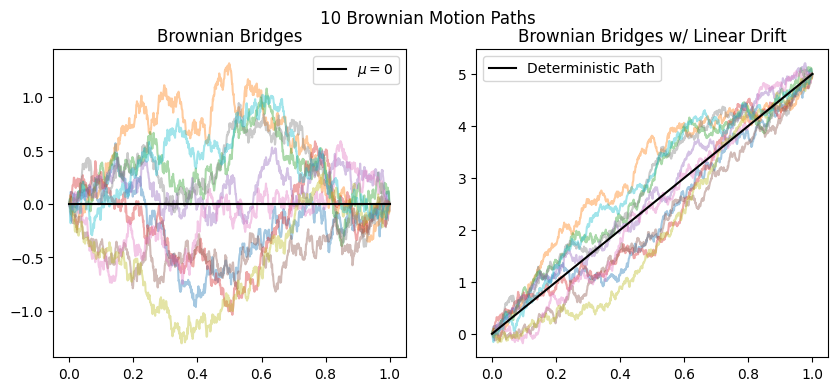

In [7]:
# Let's look at multiple Brownian motions with drift.

# Simulate many Brownian paths
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4)) 
for _ in range(10):
    Z = np.random.normal(0,1,n)
    W = np.insert(np.cumsum(np.sqrt(dt)*Z),0,0)
    W1 = W[-1]
    B = W - t*W1
    ax1.plot(t,B,alpha=0.4)
    # Deterministic vector
    x = 5*t
    Y = x + B
    ax2.plot(t,Y,alpha=0.4)

zeroline= np.zeros(n+1)  
ax1.plot(t,zeroline,alpha=1,color='black', label = "$\\mu = 0$")
ax2.plot(t,x,alpha=1,color='black', label = "Deterministic Path")
fig.suptitle("10 Brownian Motion Paths")
ax1.set_title('Brownian Bridges')
ax2.set_title('Brownian Bridges w/ Linear Drift')
ax1.legend()
ax2.legend()
plt.show()


In [ ]:
# We can see our Brownian motions on the left and our Brownian motions with drift on the right.
# The left plot shows our noise around a mean of zero.
# The right plot shows our noise around a moving mean (our deterministic vector)
# Note that the noise is the same in both cases (we didn't scale here). Peaks and valleys of different Brownian motions are consistent across plots.

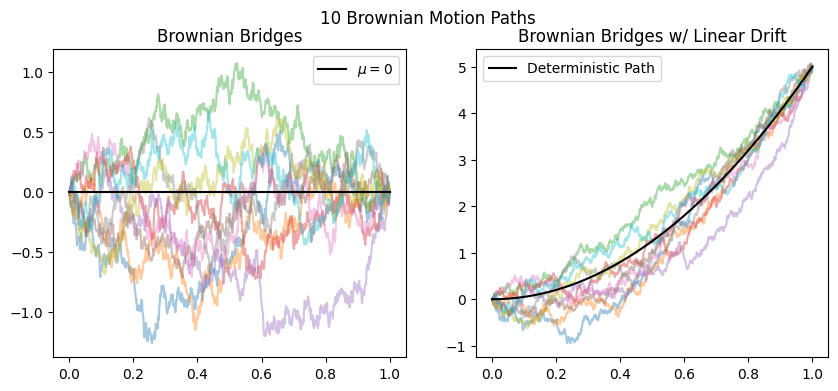

In [11]:
# Intuitively, the properties of Brownian motion with drift apply to non-linear drifts as well, i.e., non-linear deterministic vectors

# Simulate many Brownian paths
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4)) 
for _ in range(10):
    Z = np.random.normal(0,1,n)
    W = np.insert(np.cumsum(np.sqrt(dt)*Z),0,0)
    W1 = W[-1]
    B = W - t*W1
    ax1.plot(t,B,alpha=0.4)
    # Deterministic vector
    x = 5* t**2
    Y = x + B
    ax2.plot(t,Y,alpha=0.4)

zeroline= np.zeros(n+1)  
ax1.plot(t,zeroline,alpha=1,color='black', label = "$\\mu = 0$")
ax2.plot(t,x,alpha=1,color='black', label = "Deterministic Path")
fig.suptitle("10 Brownian Motion Paths")
ax1.set_title('Brownian Bridges')
ax2.set_title('Brownian Bridges w/ Linear Drift')
ax1.legend()
ax2.legend()
plt.show()


In [ ]:
# Quadratic drift
# Since all we changed was the function generating our deterministic vector, only our mean changes.

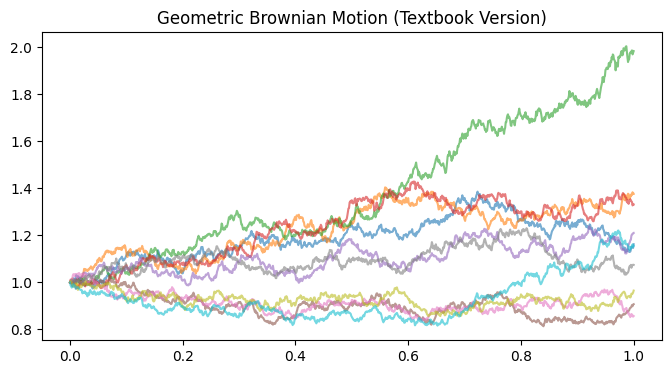

In [18]:
# Note that Brownian motion can assume negative values. For pricing, this is quite undesirable.
# We begin to explore other stochastic processes with positive ranges, motivated by contexts like pricing.

# Geometric Brownian Motion


T = 1
n = 1000
dt = T/n
t = np.linspace(0, T, n+1)
mu = 0.1
sigma = 0.2
S0 = 1

fig, ax = plt.subplots(figsize=(8,4))

for _ in range(10):
    Z = np.random.normal(0,1,n)
    B = np.insert(np.cumsum(np.sqrt(dt)*Z), 0, 0)
    X = S0 * np.exp(mu*t + sigma*B)
    ax.plot(t, X, alpha=0.6)

ax.set_title("Geometric Brownian Motion (Textbook Version)")
plt.show()

In [ ]:
# Properties of GBM
# Defined by X_{t} = e^{mu*t + sigma*B_{t}}
# X_{t} > 0 for all t. 
    # This positivity constraint solves the issue of negativity in Brownian motion from a pricing context
# ln X_{t} = mu * t + sigma * B_{t}
    # It follows that X_{t} is log-normal. 
# E[X_t] = e^{mu*t+0.5*(sigma^2)*t}
# Var(X_{T}) = (e^{2*mu*t+(sigma^2)*t})*((e^{(sigma^2)*t})-1)

# This is the conceptual basis of Black - Scholes. Will build upon this moving forward.

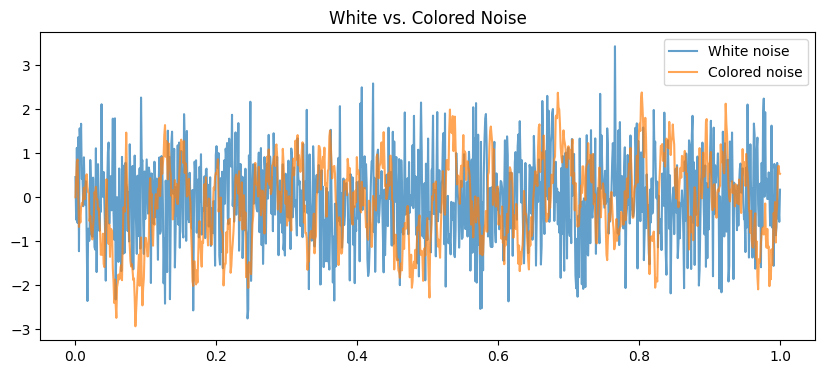

In [19]:
# White noise vs. Colored noise

# White noise is theoretical: independent Gaussian randomness at every infinitesimal instant. It is what underlies Brownian motion.
# It is too rough to observe or simulate directly because, as we've previously explored, the derivative of Brownian motion does not exist.
# Thus, we rely on colored noise, which introduces a small correlation between steps.
# This allows us to approximate white noise numerically so that we can utilize the randomness in modeling and have stable simulations.


n = 1000
T = 1
dt = T/n
t = np.linspace(0, T, n)

# White noise
white = np.random.normal(0, 1, n)

# Colored noise (simple first-order correlation)
alpha = 0.9
colored = np.zeros(n)
for i in range(1, n):
    colored[i] = alpha*colored[i-1] + np.sqrt(1-alpha**2)*np.random.normal()

plt.figure(figsize=(10,4))
plt.plot(t, white, label='White noise', alpha=0.7)
plt.plot(t, colored, label='Colored noise', alpha=0.7)
plt.legend()
plt.title("White vs. Colored Noise")
plt.show()